In [37]:
import numpy as np
import cv2 as cv
import open3d as o3d
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [39]:
imgL = cv.imread('/Users/luryand/Documents/VC/img/task04/01.jpg')
imgR = cv.imread('/Users/luryand/Documents/VC/img/task04/02.jpg')
imgL_gray = cv.cvtColor(imgL, cv.COLOR_BGR2GRAY)
imgR_gray = cv.cvtColor(imgR, cv.COLOR_BGR2GRAY)

stereo = cv.StereoSGBM_create(numDisparities=64,blockSize=9, 
                              P1=8*3*9**2, P2=32*3*9**2, 
                              disp12MaxDiff=1, uniquenessRatio=10, 
                              speckleWindowSize=0, speckleRange=0, 
                              preFilterCap=63, minDisparity=0)
disparity = stereo.compute(imgL_gray, imgR_gray).astype(np.int16)

disp_norm = cv.normalize(disparity, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
disp_blur = cv.medianBlur(disp_norm, 21)

In [ ]:
def load_image_from_url(url):
    try:
        with urllib.request.urlopen(url) as response:
            img_array = np.asarray(bytearray(response.read()), dtype=np.uint8)
            return cv.imdecode(img_array, cv.IMREAD_COLOR)
    except Exception as e:
        print(f"Erro no URL {url}: {e}")
        return None

image_urls = [
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/01.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/02.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/03.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/04.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/05.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/06.jpg"
]
imgL_gray = cv.cvtColor(imgL, cv.COLOR_BGR2GRAY)
imgR_gray = cv.cvtColor(imgR, cv.COLOR_BGR2GRAY)

stereo = cv.StereoSGBM_create(numDisparities=64,blockSize=9, 
                              P1=8*3*9**2, P2=32*3*9**2, 
                              disp12MaxDiff=1, uniquenessRatio=10, 
                              speckleWindowSize=0, speckleRange=0, 
                              preFilterCap=63, minDisparity=0)
disparity = stereo.compute(imgL_gray, imgR_gray).astype(np.int16)

disp_norm = cv.normalize(disparity, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
disp_blur = cv.medianBlur(disp_norm, 21)

In [ ]:
# Essas matrizes eu peguei da 
# Matrizes de calibração (exemplo: use sua matriz calibrada)
calib_matrix_P2 = np.array([
    [3.05667963e+03, 0.00000000e+00, 1.00993159e+03, 0],
    [0.00000000e+00, 2.93188868e+03, 1.06438845e+03, 0],
    [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0]
])
calib_matrix_P3 = calib_matrix_P2.copy()  # Use a matriz correta se tiver

cam1 = calib_matrix_P2[:, :3]
cam2 = calib_matrix_P3[:, :3]

# Parâmetros de rotação e translação
R = np.identity(3)
T = np.array([0.1, 0., 0.])

# Gere a matriz Q (reprojeção 3D)
h, w = imgL_gray.shape
Q = np.zeros((4, 4))
cv.stereoRectify(
    cameraMatrix1=cam1, cameraMatrix2=cam2,
    distCoeffs1=None, distCoeffs2=None,
    imageSize=(w, h),
    R=R, T=T,
    R1=None, R2=None, P1=None, P2=None, Q=Q,
    flags=0, alpha=0
)

print("Matriz Q (reprojeção 3D):")
print(Q)

Matriz Q (reprojeção 3D):
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.01464972e+03]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -1.06438831e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  3.07095962e+03]
 [ 0.00000000e+00  0.00000000e+00 -1.00000000e+01  0.00000000e+00]]


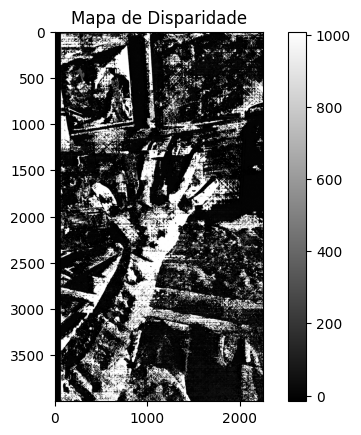

In [41]:
plt.imshow(disparity, cmap='gray')
plt.colorbar()
plt.title('Mapa de Disparidade')
plt.show()

In [42]:
# Gere a nuvem de pontos 3D
points_3D = cv.reprojectImageTo3D(disparity, Q)
colors = cv.cvtColor(imgL, cv.COLOR_BGR2RGB)
mask = (disparity > 0) & np.isfinite(disparity)
out_points = points_3D[mask]
out_colors = colors[mask]

# Função para salvar em PLY
def write_ply(filename, verts, colors):
    verts = verts.reshape(-1, 3)
    colors = colors.reshape(-1, 3)
    verts = np.hstack([verts, colors])
    ply_header = '''ply
format ascii 1.0
element vertex %(vert_num)d
property float x
property float y
property float z
property uchar red
property uchar green
property uchar blue
end_header
'''
    with open(filename, 'w') as f:
        f.write(ply_header % dict(vert_num=len(verts)))
        np.savetxt(f, verts, '%f %f %f %d %d %d')

write_ply('out.ply', out_points, out_colors)
print('PLY file salvo!')

PLY file salvo!


In [43]:
print("Shape dos pontos:", out_points.shape)
print("Coordenadas mínimas (X, Y, Z):", np.min(out_points, axis=0))
print("Coordenadas máximas (X, Y, Z):", np.max(out_points, axis=0))
print("Média (X, Y, Z):", np.mean(out_points, axis=0))
print("Desvio padrão (X, Y, Z):", np.std(out_points, axis=0))

Shape dos pontos: (3093232, 3)


Coordenadas mínimas (X, Y, Z): [-13.692781 -32.573463 -34.121773]
Coordenadas máximas (X, Y, Z): [10.562775  11.826537  -0.3046587]
Média (X, Y, Z): [-0.21426308 -1.1782072  -3.153406  ]
Desvio padrão (X, Y, Z): [1.361867  3.5323412 6.2900844]


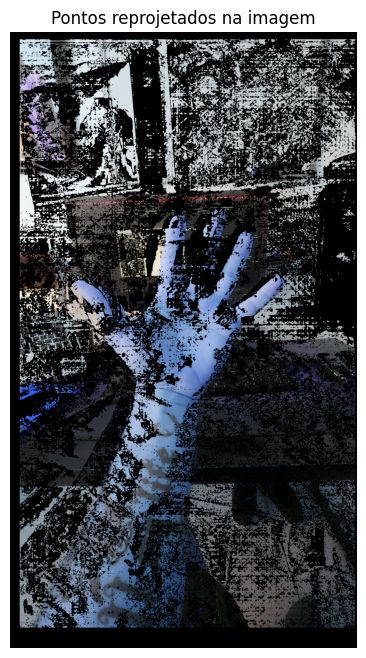

In [47]:
# Reflete X se necessário (opcional, depende do seu reprojectImageTo3D)
reflected_points = out_points.copy()
reflected_points[:, 0] *= -1

# Projeta os pontos 3D de volta para 2D usando a matriz da câmera
projected_points, _ = cv.projectPoints(
    reflected_points, np.zeros(3), np.zeros(3), 
    calib_matrix_P2[:, :3], np.zeros(5)
)
projected_points = projected_points.reshape(-1, 2)
blank_img = np.zeros_like(imgL)

for i, pt in enumerate(projected_points):
    pt_x = int(round(pt[0]))
    pt_y = int(round(pt[1]))
    if 0 <= pt_x < blank_img.shape[1] and 0 <= pt_y < blank_img.shape[0]:
        col = tuple(int(c) for c in out_colors[i])
        cv.circle(blank_img, (pt_x, pt_y), 1, col, -1)

plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(blank_img, cv.COLOR_BGR2RGB))
plt.title("Pontos reprojetados na imagem")
plt.axis('off')
plt.show()

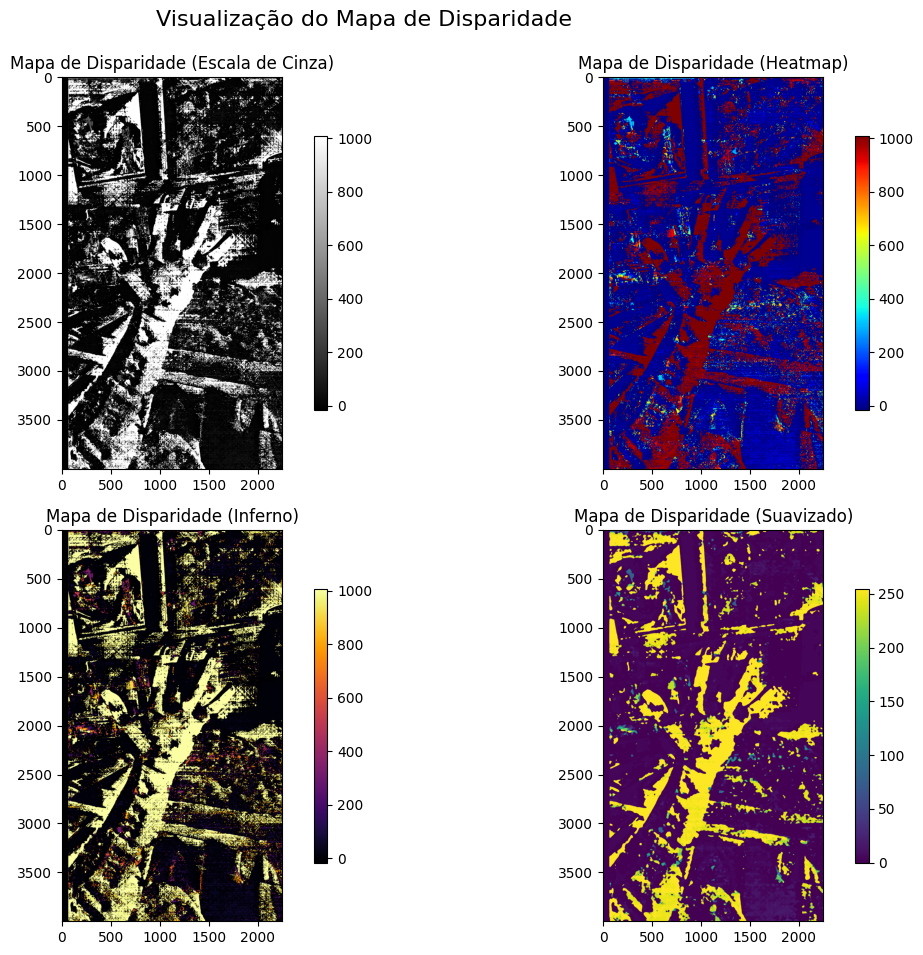

In [44]:
plt.figure(figsize=(12, 10))

# Mapa de disparidade escala de cinza
plt.subplot(221)
plt.imshow(disparity, cmap='gray')
plt.colorbar(shrink=0.7)
plt.title('Mapa de Disparidade (Escala de Cinza)', fontsize=12)

# Mapa de disparidade colormap 'jet'
plt.subplot(222)
plt.imshow(disparity, cmap='jet')
plt.colorbar(shrink=0.7)
plt.title('Mapa de Disparidade (Heatmap)', fontsize=12)

# Mapa de disparidade colormap 'inferno' 
plt.subplot(223)
plt.imshow(disparity, cmap='inferno')
plt.colorbar(shrink=0.7)
plt.title('Mapa de Disparidade (Inferno)', fontsize=12)

# Mapa de disparidade com blur
plt.subplot(224)
plt.imshow(disp_blur, cmap='viridis')
plt.colorbar(shrink=0.7)
plt.title('Mapa de Disparidade (Suavizado)', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Visualização do Mapa de Disparidade', fontsize=16)
plt.show()

In [ ]:
# Visualização interativa avançada da nuvem de pontos 3D
idx = np.random.choice(len(out_points), size=min(30000, len(out_points)), replace=False)
pts = np.asarray(out_points)[idx]
cols = np.asarray(out_colors)[idx] / 255.0

# Criar uma visualização Plotly mais elaborada
fig = go.Figure(data=[go.Scatter3d(
    x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
    mode='markers',
    marker=dict(
        size=2,
        color=cols,  # RGB colors
        opacity=0.8
    ),
    name='Nuvem de pontos'
)])

# Adicionar planos de referência (opcional)
max_range = max(
    np.max(pts[:, 0]) - np.min(pts[:, 0]), 
    np.max(pts[:, 1]) - np.min(pts[:, 1]),
    np.max(pts[:, 2]) - np.min(pts[:, 2])
)
mean_x = np.mean([np.min(pts[:, 0]), np.max(pts[:, 0])])
mean_y = np.mean([np.min(pts[:, 1]), np.max(pts[:, 1])])
mean_z = np.mean([np.min(pts[:, 2]), np.max(pts[:, 2])])

# Configuração aprimorada de layout
fig.update_layout(
    title={
        'text': "Visualização Interativa da Nuvem de Pontos 3D",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    scene=dict(
        xaxis_title='Eixo X',
        yaxis_title='Eixo Y',
        zaxis_title='Eixo Z',
        xaxis=dict(showbackground=True, backgroundcolor="rgb(230, 230,230)", gridcolor='white'),
        yaxis=dict(showbackground=True, backgroundcolor="rgb(230, 230,230)", gridcolor='white'),
        zaxis=dict(showbackground=True, backgroundcolor="rgb(230, 230,230)", gridcolor='white'),
        camera=dict(
            up=dict(x=0, y=0, z=1),
            eye=dict(x=1.5, y=1.5, z=1.2)
        ),
        aspectmode='auto'
    ),
    margin=dict(l=0, r=0, b=0, t=0),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()